# Exploratory Data Analysis
Looking at the S&P 500 data before any modeling, to sanity-check it and understand what I'm working with.

In [1]:
import sys
sys.path.append("..")

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from src.data_loader import get_data
from src.features import compute_log_returns, compute_volatility, create_features, compute_volume_features
from src import config

%matplotlib inline

## 1. Load and inspect raw data

In [2]:
df = get_data(ticker=config.TICKER, start=config.START_DATE, end=config.END_DATE)
print(df.shape)
df.head()

Data saved to /Users/mav/Quant Projects/stock-volatility-predictor/data/raw/sp500_raw.csv
(2014, 2)


Price,Close,Volume
Date,,
2015-01-02,2058.199951,2708700000
2015-01-05,2020.579956,3799120000
2015-01-06,2002.609985,4460110000
2015-01-07,2025.900024,3805480000
2015-01-08,2062.139893,3934010000


In [3]:
df.describe()

Price,Close,Volume
count,2014.000000,2.014000e+03
mean,2981.709454,4.016949e+09
std,812.245018,9.942605e+08
min,1829.079956,1.296530e+09
25%,2265.184937,3.383488e+09
50%,2798.325073,3.801770e+09
75%,3678.309937,4.414868e+09
max,4796.560059,9.976520e+09


In [4]:
# Check for gaps in the trading calendar (weekends are expected; anything larger is worth a look)
gap_days = df.index.to_series().diff().dt.days
print("Largest gaps between consecutive trading days:")
print(gap_days.sort_values(ascending=False).head(10))

Largest gaps between consecutive trading days:
Date
2022-07-05    4.0
2017-12-26    4.0
2018-04-02    4.0
2015-07-06    4.0
2016-01-19    4.0
2015-04-06    4.0
2020-07-06    4.0
2021-02-16    4.0
2017-05-30    4.0
2018-02-20    4.0
Name: Date, dtype: float64


## 2. Price series and log returns

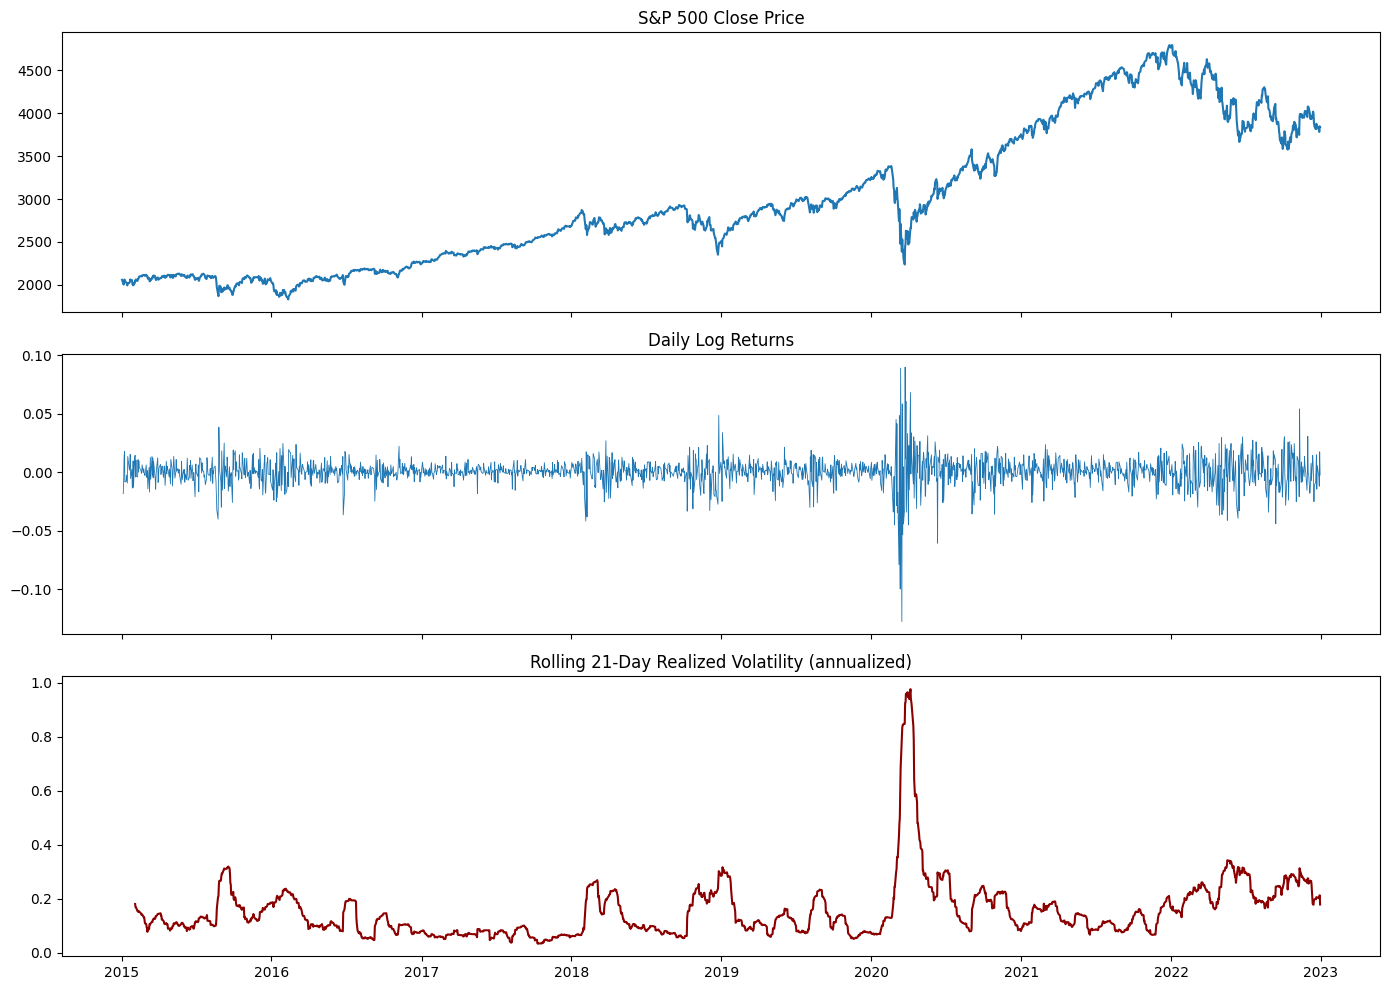

In [5]:
df = compute_log_returns(df)
df = compute_volatility(df, window=config.VOLATILITY_WINDOW)

fig, axes = plt.subplots(3, 1, figsize=(14, 10), sharex=True)

axes[0].plot(df.index, df["Close"])
axes[0].set_title("S&P 500 Close Price")

axes[1].plot(df.index, df["log_return"], linewidth=0.6)
axes[1].set_title("Daily Log Returns")

axes[2].plot(df.index, df["volatility"], color="darkred")
axes[2].set_title(f"Rolling {config.VOLATILITY_WINDOW}-Day Realized Volatility (annualized)")

plt.tight_layout()
plt.savefig("../outputs/plots/price_returns_volatility.png", dpi=150)
plt.show()

Volatility clustering is visible here — quiet stretches and turbulent stretches both persist for a while rather than jumping around randomly day to day. This is the whole premise the project's models are trying to exploit.

## 3. Squared returns (a noisier, single-day proxy for volatility)

Data saved to /Users/mav/Quant Projects/stock-volatility-predictor/data/raw/sp500_raw.csv
Plot saved to ../outputs/plots/returns_and_squared_returns.png


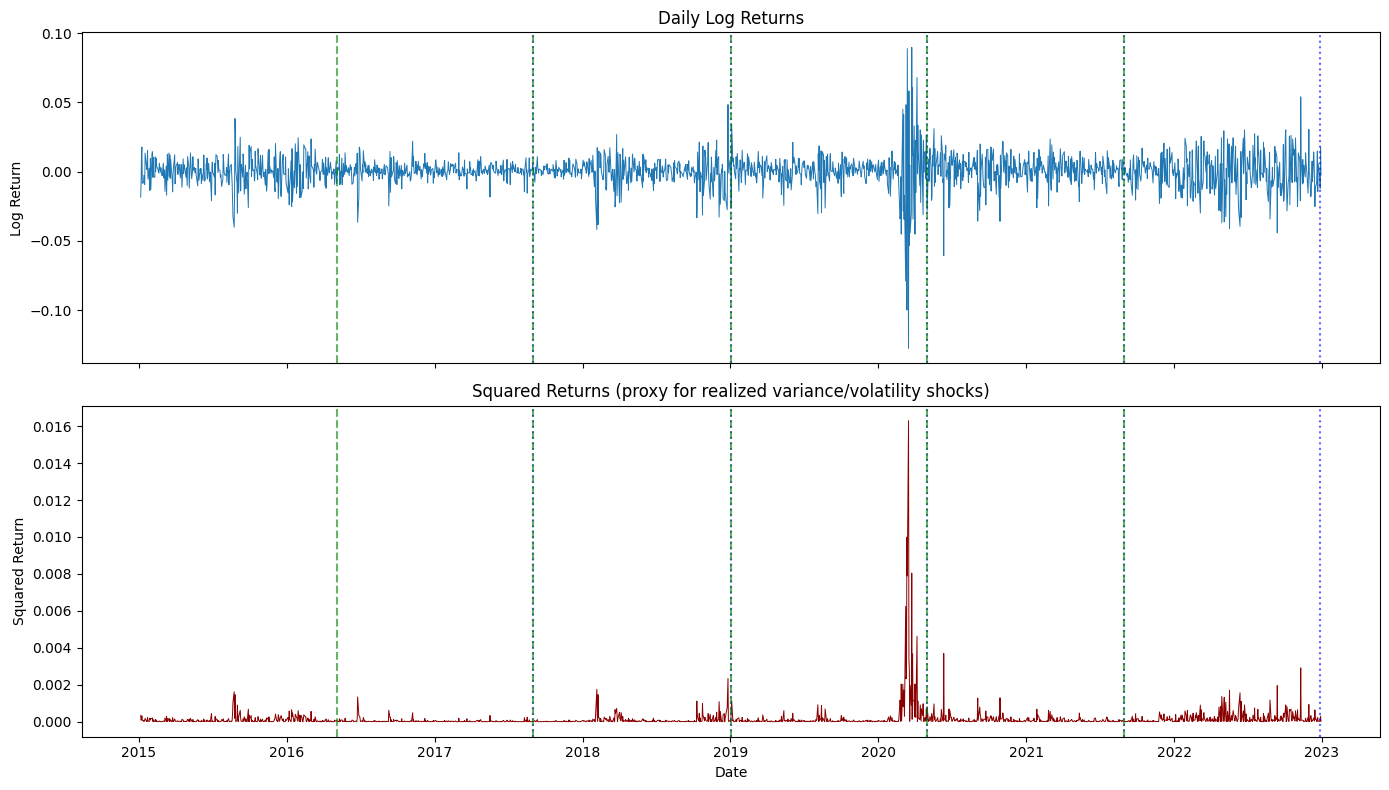

In [6]:
from src.plot_returns import plot_returns_and_squared_returns

plot_returns_and_squared_returns(n_splits=config.N_SPLITS, save_path="../outputs/plots/returns_and_squared_returns.png")

## 4. Correlation between lag features — visual evidence of multicollinearity

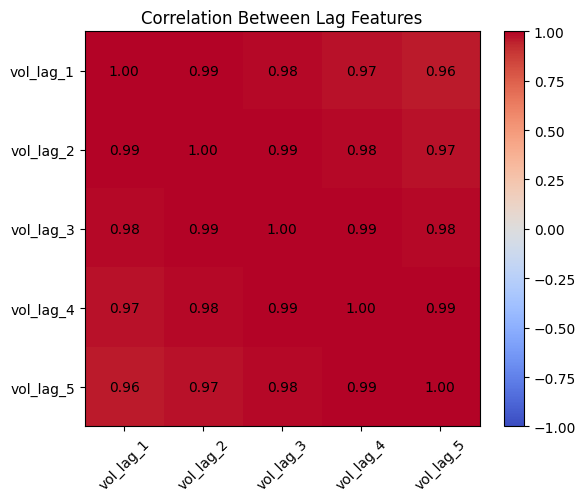

In [7]:
df_feat = create_features(df, n_lags=config.N_LAGS)
lag_cols = [f"vol_lag_{i}" for i in range(1, config.N_LAGS + 1)]
corr = df_feat[lag_cols].dropna().corr()

fig, ax = plt.subplots(figsize=(6, 5))
im = ax.imshow(corr, cmap="coolwarm", vmin=-1, vmax=1)
ax.set_xticks(range(len(lag_cols)))
ax.set_yticks(range(len(lag_cols)))
ax.set_xticklabels(lag_cols, rotation=45)
ax.set_yticklabels(lag_cols)
for i in range(len(lag_cols)):
    for j in range(len(lag_cols)):
        ax.text(j, i, f"{corr.iloc[i, j]:.2f}", ha="center", va="center")
plt.colorbar(im)
plt.title("Correlation Between Lag Features")
plt.tight_layout()
plt.savefig("../outputs/plots/lag_feature_correlation.png", dpi=150)
plt.show()

This is the direct evidence behind the multicollinearity finding in the README: the lag features are all highly correlated with each other, which is why unregularized gradient descent and sklearn's OLS landed on different weight vectors despite similar loss, and why Ridge/Lasso were worth adding.

## 5. Basic volatility statistics

In [8]:
vol = df["volatility"].dropna()
print(f"Mean: {vol.mean():.4f}")
print(f"Std: {vol.std():.4f}")
print(f"Min: {vol.min():.4f}")
print(f"Max: {vol.max():.4f}")
print(f"Date of max volatility: {vol.idxmax().date()}")

Mean: 0.1547
Std: 0.1110
Min: 0.0347
Max: 0.9756
Date of max volatility: 2020-04-06
